Ejemplo de conversión básica de un directorio de imágenes en un dataset, con el objeto dataset de Hugging Face.

In [1]:
import sys
import os
from pathlib import Path
from datasets import load_dataset,DownloadMode,ReadInstruction


c:\Users\ruben\anaconda3\envs\syft_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Dependencies
# !pip install datasets
# !pip install torchvision

In [3]:
# Python path

path_python_local_modules='/home/tfg0/TFG/workdir/src'
sys.path.insert(0,path_python_local_modules)

In [7]:
# Clases
import matplotlib.pyplot as plt

class Data_Preprocessing:
    def __init__(
            self,
            data_path=Path("./data/"), #Ruta a un directorio de imagenes con dos clases
            image_size=[256,256], # Tamaño de la imagen.
            image_processor=None, # Procesamiento de batches de imagenes justo antes de ser consumidas por el modelo
            filter_names=[], #TODO
            num_proc=1, # workers
            prep_batch_size=32, # Tam. batches
            download_mode=DownloadMode.REUSE_DATASET_IF_EXISTS, # Dataset download mode
            keep_in_memory=True # Opcion para el Dataset

    ):
        #TODO
        # Check de data_path
        self.data_path=data_path
        self.image_size=image_size
        if image_processor is None:
            self.image_processor=self._default_image_processor
        self.num_proc=num_proc
        self.batch_size=prep_batch_size
        self.download_mode=download_mode
        self.keep_in_memory=keep_in_memory
        self._build_dataset()
        # Transformacion que solo se aplica una vez
        self.dataset=self.dataset.map(self._prepare,
                                      batched=True,
                                      batch_size=self.batch_size,
                                      num_proc=self.num_proc)
        self.dataset.set_transform(lambda ex : self._transform(ex,None))

    def show_sample(self,sample,show_image=True):

        image=self.dataset[sample]["proc_image"]
        label=self.dataset[sample]["label"]
        name=self.dataset[sample]["name"]
        print(f"Name:{name} Label:{label}")
        if show_image:
            plt.imshow(image) # imshow espera fila, columna, canal. De los datos viene como: canal, columna, fila.


    def _build_dataset(self):
        _ri=ReadInstruction('train',to=100,unit='%') # Solo un split
        self.dataset=load_dataset("imagefolder",
                data_dir=self.data_path,
                split=_ri,
                download_mode=self.download_mode,
                keep_in_memory=True)


    def _prepare(self,examples):
        from torchvision.transforms.v2 import Resize, InterpolationMode
        
        # _prepare se aplica una vez a todo el dataset
        transform=Resize(self.image_size,
                         interpolation=InterpolationMode.BILINEAR)
        examples["image"] = [transform(im.convert("RGB")) for im in examples["image"]]
        return examples

    def _transform(self, examples, _trans=None):
        # _transform se aplica cada vez que se usa el dataset para instanciar imagenes.
        if "image" in examples.keys():
            if _trans is not None:
                examples["proc_image"]=[_trans(img.convert("RGB")) for img in examples["image"]]
            else:
                examples["proc_image"]=[ img.convert("RGB") for img in examples["image"]]
            
            procesado = self.image_processor(examples["proc_image"])

            if isinstance(procesado, dict) and "pixel_values" in procesado:
                examples["pixel_values"] = procesado["pixel_values"]
            else:
                examples["pixel_values"] = procesado

        return examples

    def _default_image_processor(self,examples):
        return examples







In [5]:

data_batch_size=32

data_path=Path('../../trial_0')




In [8]:
preprocessed=Data_Preprocessing(
    data_path=data_path,
    prep_batch_size=data_batch_size)




Resolving data files:   0%|          | 0/81 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/22 [00:00<?, ?it/s]

Map (num_proc=1):   0%|          | 0/80 [00:00<?, ? examples/s]

Name:drishtiGS_100_crop.png Label:0


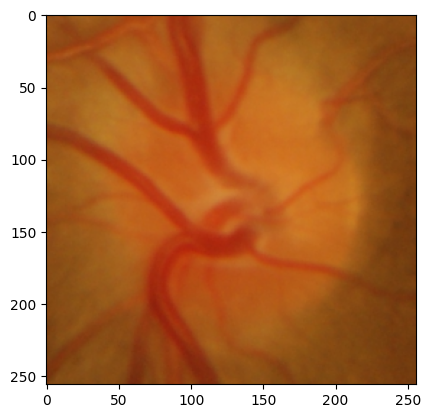

In [9]:
# Cambiar el índice para ir mostrando imágenes del dataset
preprocessed.show_sample(3,show_image=True)

In [10]:
print(preprocessed.dataset)

Dataset({
    features: ['image', 'name', 'label'],
    num_rows: 80
})


In [ ]:
# # Aplico la transformación a todo el dataset para poder guardarlo sin errores
# dataset_final = preprocessed.dataset.map(
#     lambda ex: preprocessed._transform(ex, None), 
#     batched=True
# )

# # 1. Limpiamos cualquier transformación dinámica heredada
# dataset_final.set_transform(None) 
# # (Alternativamente puedes usar: dataset_final.reset_format())


# dataset_final.save_to_disk('/home/tfg0/TFG/workdir/preprocessed_dataset')

# Train Resnet50

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights

ready_dataset = preprocessed.dataset
ready_dataset.set_format(type="torch", columns=["image", "label"])
total_images = len(ready_dataset)

dataloader = DataLoader(ready_dataset, batch_size=16, shuffle=True)

In [20]:
# 1. Comprobar si tienes GPU (CUDA) disponible, si no, usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# 2. Cargar el modelo preentrenado
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# 3. Congelar todas las capas (no queremos destruir el conocimiento previo)
for param in model.parameters():
    param.requires_grad = False

# 4. Reemplazar la ÚLTIMA capa para adaptarla a tus 2 clases
# Por defecto, la última capa (fc) de ResNet50 clasifica 1000 clases.
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2) # Cambia el '2' si tienes un número diferente de clases

# Mover el modelo a tu tarjeta gráfica o procesador
model = model.to(device)

Entrenando en: cuda


In [21]:
# Función de pérdida para clasificación multiclase/binaria
criterion = nn.CrossEntropyLoss()

# Optimizador: SOLO actualizamos los parámetros de la nueva capa (model.fc)
# Un learning rate (lr) de 0.001 es un buen punto de partida
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Número de pasadas completas por el dataset
num_epochs = 50 

print("Iniciando entrenamiento...")

for epoch in range(num_epochs):
    model.train() # Ponemos el modelo en modo entrenamiento
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    for batch in dataloader:
        # 1. Obtener los datos y moverlos a la GPU/CPU
        # Si tus imágenes tienen un shape [batch, 1, canales, alto, ancho] por culpa
        # de procesamientos extraños, usa inputs.squeeze(1) para arreglarlo.
        inputs = batch["image"].to(device) 
        labels = batch["label"].to(device)
        
        # 2. Reiniciar los gradientes del optimizador
        optimizer.zero_grad()
        
        # 3. Forward pass (pasar las imágenes por el modelo)
        outputs = model(inputs.float() / 255.0)
        loss = criterion(outputs, labels)
        
        # 4. Backward pass (calcular el error y ajustar los pesos)
        loss.backward()
        optimizer.step()
        
        # 5. Calcular estadísticas
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
        
    # Calcular promedios de la época
    epoch_loss = running_loss / len(ready_dataset)
    epoch_acc = (correct_predictions / total_predictions) * 100
    
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("¡Entrenamiento finalizado!")

Iniciando entrenamiento...
Epoch 1/10 | Loss: 0.6309 | Accuracy: 67.50%
Epoch 2/10 | Loss: 0.6125 | Accuracy: 68.75%
Epoch 3/10 | Loss: 0.5500 | Accuracy: 68.75%
Epoch 4/10 | Loss: 0.5024 | Accuracy: 80.00%
Epoch 5/10 | Loss: 0.4808 | Accuracy: 83.75%
Epoch 6/10 | Loss: 0.4446 | Accuracy: 77.50%
Epoch 7/10 | Loss: 0.4259 | Accuracy: 76.25%
Epoch 8/10 | Loss: 0.3928 | Accuracy: 81.25%
Epoch 9/10 | Loss: 0.4005 | Accuracy: 90.00%
Epoch 10/10 | Loss: 0.3476 | Accuracy: 92.50%
¡Entrenamiento finalizado!
